In [1]:
# Loading requied libraries
import pandas as pd
import numpy as np

In [2]:
# Loading the dataset
df=pd.read_csv(r"C:\Users\OMEN\OneDrive\Desktop\bank+marketing\bank\bank-full.csv", sep=';')

In [3]:
# First few rows of the datatset
print("Fist few rows of the dataset:")
print(df.head())
# Basic information of the dataset
print("\nBasic Information of the Datset:")
print(df.info())

# Features in the dataset
df.columns# Features in the dataset
print("\nFeatures in the dataset:")
print(df.columns)

Fist few rows of the dataset:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

Basic Information of the Datset:
<class 'pandas.core.frame.DataFrame'>
RangeInde

In [4]:

from scipy import stats

In [5]:
# Missing values
print("\nMissing values in the datset:")
print(df.isnull().sum())

# Check duplicates
dupli = df.duplicated().sum()
print(f"\nThe total number of duplicate rows: {dupli}")

# Detect outliers using Z-score
numCols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\nOutlier detection using Z-score(> 3):")
for col in numCols:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    outliers = (z_scores > 3).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)")

# Remove outliers
for col in numCols:
    z_scores = np.abs(stats.zscore(df[col]))
    df = df[z_scores < 3]

print(f"\nAfter removing outliers: {df.shape}")

# Target variable converted into binary
df['target'] = df['y'].map({'yes': 1, 'no': 0})
print("\nTarget variable encoded: 'yes'=1, 'no'=0")
print(df['target'].value_counts())

# Saved the cleaned dataset for convience
df.to_csv('cleaned dataset.csv', index=False)
print(f"\nCleaned dataset saved")
print(f"Final shape: {df.shape}")


Missing values in the datset:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

The total number of duplicate rows: 0

Outlier detection using Z-score(> 3):
age: 381 outliers (0.84%)
balance: 745 outliers (1.65%)
day: 0 outliers (0.00%)
duration: 963 outliers (2.13%)
campaign: 840 outliers (1.86%)
pdays: 1723 outliers (3.81%)
previous: 582 outliers (1.29%)

After removing outliers: (40340, 17)

Target variable encoded: 'yes'=1, 'no'=0
target
0    36274
1     4066
Name: count, dtype: int64

Cleaned dataset saved
Final shape: (40340, 18)


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


Statistical summary:
                age       balance           day      duration      campaign  \
count  40340.000000  40340.000000  40340.000000  40340.000000  40340.000000   
mean      40.651091   1076.348785     15.806321    235.839118      2.462221   
std       10.083501   1705.252684      8.358237    190.357566      1.949710   
min       18.000000  -6847.000000      1.000000      0.000000      1.000000   
25%       33.000000     66.000000      8.000000    104.000000      1.000000   
50%       39.000000    429.000000     16.000000    178.000000      2.000000   
75%       48.000000   1342.000000     21.000000    306.000000      3.000000   
max       72.000000  10287.000000     31.000000   1029.000000     12.000000   

              pdays      previous        target  
count  40340.000000  40340.000000  40340.000000  
mean      26.464105      0.360064      0.100793  
std       74.401929      1.065274      0.301059  
min       -1.000000      0.000000      0.000000  
25%       -1.000

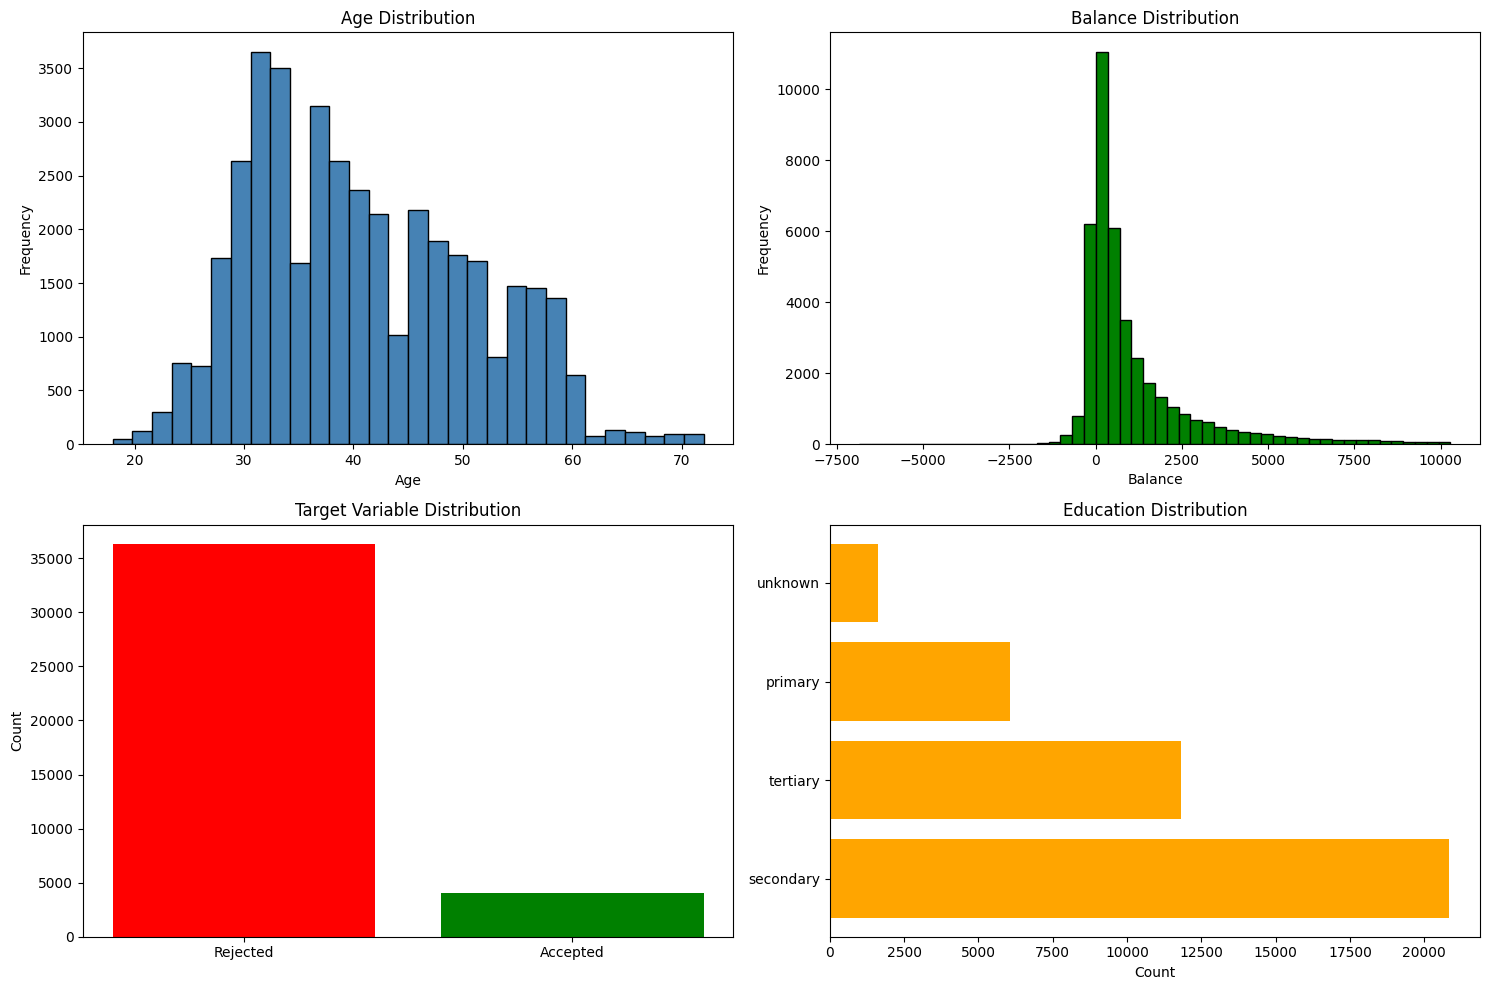

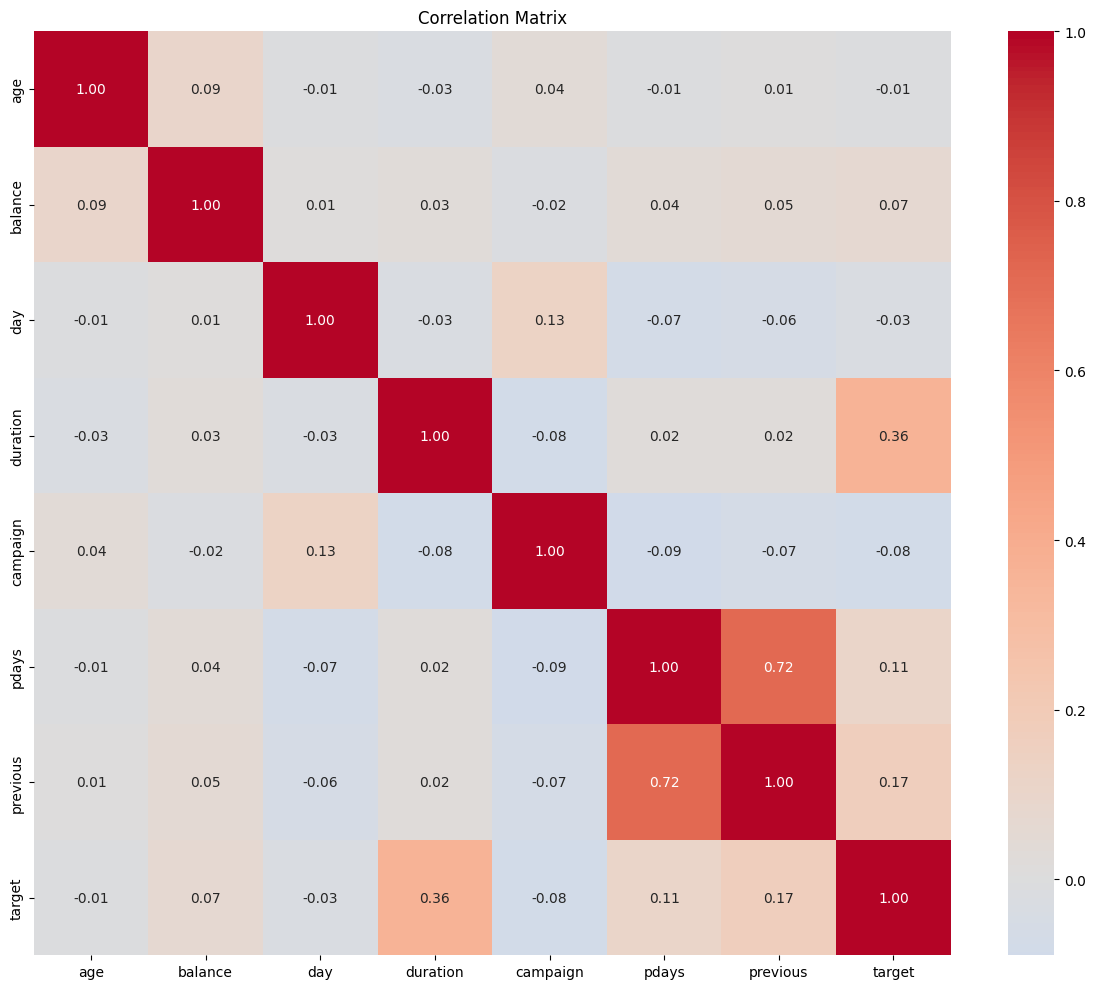

In [7]:
# Statistical summary
# Redefine numCols to include 'target' as it's now a numerical column
numCols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nStatistical summary:")
print(df[numCols].describe())

# Categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns: {categorical_cols}")

for col in categorical_cols:
    print(f"\n{col} distribution:")
    print(df[col].value_counts())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age distribution
axes[0, 0].hist(df['age'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Balance distribution
axes[0, 1].hist(df['balance'], bins=50, color='green', edgecolor='black')
axes[0, 1].set_title('Balance Distribution')
axes[0, 1].set_xlabel('Balance')
axes[0, 1].set_ylabel('Frequency')

# Target distribution
target_counts = df['target'].value_counts()
axes[1, 0].bar(['Rejected', 'Accepted'], target_counts.values,
               color=['red', 'green'])
axes[1, 0].set_title('Target Variable Distribution')
axes[1, 0].set_ylabel('Count')

# Education distribution
education_counts = df['education'].value_counts()
axes[1, 1].barh(education_counts.index, education_counts.values, color='orange')
axes[1, 1].set_title('Education Distribution')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=300)
print("\nVisualization saved: eda_plots.png")

# Correlation matrix
# numCols should now include 'target' if recalculated
correlation = df[numCols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation.png', dpi=300)
print("Correlation matrix saved: correlation.png")

# Top correlations with target
print("\nTop correlations with target:")
print(correlation['target'].sort_values(ascending=False).head(10))

# Acceptance rate by education
acceptance_by_edu = df.groupby('education')['target'].mean().sort_values(ascending=False)
print("\nAcceptance rate by education:")
print(acceptance_by_edu)

# Acceptance rate by job
acceptByJob = df.groupby('job')['target'].mean().sort_values(ascending=False)
print("\nAcceptance rate by job:")
print(acceptByJob)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import warnings

In [9]:
df = pd.read_csv('cleaned dataset.csv')
print(f"\nDataset shape: {df.shape}")
print(f"Initial features: {df.shape[1]}")

# 1. Balance-related features
df['balance_positive'] = (df['balance'] > 0).astype(int)
df['high_balance'] = (df['balance'] > df['balance'].median()).astype(int)
print("✓ Created balance features")

# 2. Age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100],
                          labels=['young', 'middle', 'senior', 'elderly'])

# 3. Contact frequency features
df['contacted_before'] = (df['previous'] > 0).astype(int)
df['recent_contact'] = (df['pdays'] != -1).astype(int)
print("Created contact frequency features")

# 4. Campaign intensity
df['multiple_contacts'] = (df['campaign'] > 2).astype(int)
print("Created campaign intensity feature")

# 5. Duration categories
df['duration_category'] = pd.cut(df['duration'], bins=[0, 100, 300, 1000, 5000],labels=['very_short', 'short', 'medium', 'long'])
print("✓ Created duration categories")

# 6. Economic indicators
df['month_start'] = (df['day'] <= 10).astype(int)
df['month_end'] = (df['day'] >= 20).astype(int)
print("✓ Created timing features")

print(f"\nTotal new features created: 9")
print(f"Total features now: {df.shape[1]}")

# Encode categorical variables
categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
                    'loan', 'contact', 'month', 'poutcome', 'age_group',
                    'duration_category']

label_encoders = {}
encoded_cols = []

for col in categorical_cols:
    le = LabelEncoder()
    encoded_col_name = col + '_encoded'
    df[encoded_col_name] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    encoded_cols.append(encoded_col_name)
    print(f"{col}: {len(le.classes_)} unique values → {encoded_col_name}")

print(f"\n Total categorical features encoded: {len(categorical_cols)}")

# Numerical features
numerical_features = ['age', 'balance', 'day', 'duration', 'campaign',
                      'pdays', 'previous']

# Engineered binary features
engineered_features = ['balance_positive', 'high_balance', 'contacted_before',
                       'recent_contact', 'multiple_contacts', 'month_start',
                       'month_end']

# Combining all the features
feature_cols = numerical_features + engineered_features + encoded_cols

print(f"\nFeature breakdown:")
print(f"  Numerical features: {len(numerical_features)}")
print(f"  Engineered features: {len(engineered_features)}")
print(f"  Encoded categorical: {len(encoded_cols)}")
print(f"  Total features: {len(feature_cols)}")

# Create feature matrix and target
X = df[feature_cols]
y = df['target']

print(f"\Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")

# Display feature names
print(f"\nFinal feature list:")
for idx, col in enumerate(feature_cols, 1):
    print(f"  {idx:2d}. {col}")

# Save engineered dataset
df.to_csv('bank-marketing-engineered.csv', index=False)

<>:75: SyntaxWarning: invalid escape sequence '\F'
<>:75: SyntaxWarning: invalid escape sequence '\F'
C:\Users\OMEN\AppData\Local\Temp\ipykernel_22520\770164451.py:75: SyntaxWarning: invalid escape sequence '\F'
  print(f"\Feature matrix shape: {X.shape}")



Dataset shape: (40340, 18)
Initial features: 18
✓ Created balance features
Created contact frequency features
Created campaign intensity feature
✓ Created duration categories
✓ Created timing features

Total new features created: 9
Total features now: 27
job: 12 unique values → job_encoded
marital: 3 unique values → marital_encoded
education: 4 unique values → education_encoded
default: 2 unique values → default_encoded
housing: 2 unique values → housing_encoded
loan: 2 unique values → loan_encoded
contact: 3 unique values → contact_encoded
month: 12 unique values → month_encoded
poutcome: 4 unique values → poutcome_encoded
age_group: 4 unique values → age_group_encoded
duration_category: 5 unique values → duration_category_encoded

 Total categorical features encoded: 11

Feature breakdown:
  Numerical features: 7
  Engineered features: 7
  Encoded categorical: 11
  Total features: 25
\Feature matrix shape: (40340, 25)
Target variable shape: (40340,)

Final feature list:
   1. age
  

In [10]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nTraining target distribution:")
train_dist = y_train.value_counts()
print(f"  Class 0 (Rejected): {train_dist[0]} ({train_dist[0]/len(y_train)*100:.2f}%)")
print(f"  Class 1 (Accepted): {train_dist[1]} ({train_dist[1]/len(y_train)*100:.2f}%)")

print(f"\nTest target distribution:")
test_dist = y_test.value_counts()
print(f"  Class 0 (Rejected): {test_dist[0]} ({test_dist[0]/len(y_test)*100:.2f}%)")
print(f"  Class 1 (Accepted): {test_dist[1]} ({test_dist[1]/len(y_test)*100:.2f}%)")

print(f"\ Data split completed with stratification")


# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Features scaled using StandardScaler")
print(f"✓ Training data scaled: {X_train_scaled.shape}")
print(f"✓ Test data scaled: {X_test_scaled.shape}")

# Display scaling statistics for first 5 features
print(f"\nScaling statistics (first 5 features):")
print(f"{'Feature':<20} {'Mean':>10} {'Std':>10}")
print("-"*42)
for i in range(min(5, len(feature_cols))):
    print(f"{feature_cols[i]:<20} {scaler.mean_[i]:>10.2f} {scaler.scale_[i]:>10.2f}")

# Check class distribution before SMOTE
print(f"\nBefore SMOTE:")
print(f"  Class 0 (Rejected): {(y_train == 0).sum()}")
print(f"  Class 1 (Accepted): {(y_train == 1).sum()}")
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"  Minority class percentage: {(y_train == 1).sum()/len(y_train)*100:.2f}%")

# Apply SMOTE
print(f"\nApplying SMOTE...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Check class distribution after SMOTE
print(f"\nAfter SMOTE:")
print(f"  Class 0 (Rejected): {(y_train_balanced == 0).sum()}")
print(f"  Class 1 (Accepted): {(y_train_balanced == 1).sum()}")
print(f"  Imbalance ratio: 1:1")
print(f"  Total training samples: {len(y_train_balanced)}")


<>:19: SyntaxWarning: invalid escape sequence '\ '
<>:19: SyntaxWarning: invalid escape sequence '\ '
C:\Users\OMEN\AppData\Local\Temp\ipykernel_22520\2889207137.py:19: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Data split completed with stratification")



Training set: 32272 samples (80.0%)
Test set: 8068 samples (20.0%)

Training target distribution:
  Class 0 (Rejected): 29019 (89.92%)
  Class 1 (Accepted): 3253 (10.08%)

Test target distribution:
  Class 0 (Rejected): 7255 (89.92%)
  Class 1 (Accepted): 813 (10.08%)
\ Data split completed with stratification

✓ Features scaled using StandardScaler
✓ Training data scaled: (32272, 25)
✓ Test data scaled: (8068, 25)

Scaling statistics (first 5 features):
Feature                    Mean        Std
------------------------------------------
age                       40.62      10.05
balance                 1069.22    1690.89
day                       15.78       8.36
duration                 235.28     189.87
campaign                   2.46       1.94

Before SMOTE:
  Class 0 (Rejected): 29019
  Class 1 (Accepted): 3253
  Imbalance ratio: 8.92:1
  Minority class percentage: 10.08%

Applying SMOTE...

After SMOTE:
  Class 0 (Rejected): 29019
  Class 1 (Accepted): 29019
  Imbalance ratio:

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
import pickle
import warnings

Model Training

In [12]:
warnings.filterwarnings('ignore')

print("="*80)
print("MODEL TRAINING & EVALUATION")
print("="*80)

# Load engineered dataset
df = pd.read_csv('bank-marketing-engineered.csv')
print(f"\nDataset loaded: {df.shape}")

# Prepare data (same as Stage 2)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Feature selection
feature_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 
                'previous', 'balance_positive', 'high_balance', 
                'contacted_before', 'recent_contact', 'multiple_contacts',
                'month_start', 'month_end', 'job_encoded', 'marital_encoded',
                'education_encoded', 'default_encoded', 'housing_encoded',
                'loan_encoded', 'contact_encoded', 'month_encoded',
                'poutcome_encoded', 'age_group_encoded', 
                'duration_category_encoded']

X = df[feature_cols]
y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Training samples (balanced): {len(X_train_balanced)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {len(feature_cols)}")

MODEL TRAINING & EVALUATION

Dataset loaded: (40340, 38)
Training samples (balanced): 58038
Test samples: 8068
Features: 25


**Logistic Regression**

In [13]:
models = {}
# Model 1: Logistic Regression
print("\n1. Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_balanced, y_train_balanced)
models['Logistic Regression'] = lr_model
print("   ✓ Completed")

print("\n2. Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_balanced, y_train_balanced)
models['Random Forest'] = rf_model
print("   ✓ Completed")

print("\n3. Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_balanced, y_train_balanced)
models['Gradient Boosting'] = gb_model
print("   ✓ Completed")


1. Training Logistic Regression...
   ✓ Completed

2. Training Random Forest...
   ✓ Completed

3. Training Gradient Boosting...
   ✓ Completed


Evaluation

In [14]:
print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

results = {}
print(models)

for name, model in models.items():
    print(f"\n{'-'*80}")
    print(f"MODEL: {name}")
    print(f"{'-'*80}")
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    # Display metrics
    print(f"\nPerformance Metrics:")
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives:  {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives:  {tp}")
    
    # Classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=['Rejected', 'Accepted'],
                                digits=4))


MODEL EVALUATION
{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42), 'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42), 'Gradient Boosting': GradientBoostingClassifier(random_state=42)}

--------------------------------------------------------------------------------
MODEL: Logistic Regression
--------------------------------------------------------------------------------

Performance Metrics:
  Accuracy:  0.8220 (82.20%)
  Precision: 0.3363
  Recall:    0.7872
  F1-Score:  0.4713
  ROC-AUC:   0.8865

Confusion Matrix:
  True Negatives:  5992
  False Positives: 1263
  False Negatives: 173
  True Positives:  640

Detailed Classification Report:
              precision    recall  f1-score   support

    Rejected     0.9719    0.8259    0.8930      7255
    Accepted     0.3363    0.7872    0.4713       813

    accuracy                         0.8220      8068
   macro avg     0.6541    0.8066    0.6821      8068
weighted avg     0.9079    0.822